# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# UV News Data Input

In [2]:
import pandas as pd
import numpy as np

true_path = '/content/drive/MyDrive/Fake News Project Group/True.csv'
fake_path = '/content/drive/MyDrive/Fake News Project Group/Fake.csv'

true_df = pd.read_csv(true_path)
fake_df = pd.read_csv(fake_path)

In [3]:
display(true_df)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [4]:
display(fake_df)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


# Data Visualization

/tmp/ipykernel_3129/3813042907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="coolwarm", data=true_df).set_title('True News Subject Distribution')


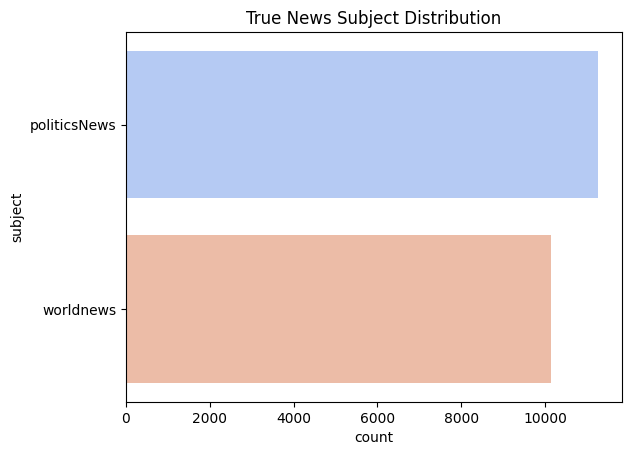

/tmp/ipykernel_3129/3813042907.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="coolwarm", data=fake_df).set_title('Fake News Subject Distribution')


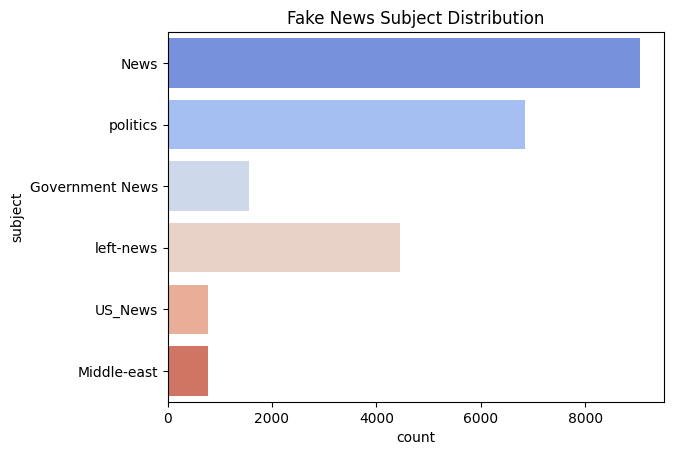

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y="subject", palette="coolwarm", data=true_df).set_title('True News Subject Distribution')
plt.show()

sns.countplot(y="subject", palette="coolwarm", data=fake_df).set_title('Fake News Subject Distribution')
plt.show()

## Real News Word Cloud

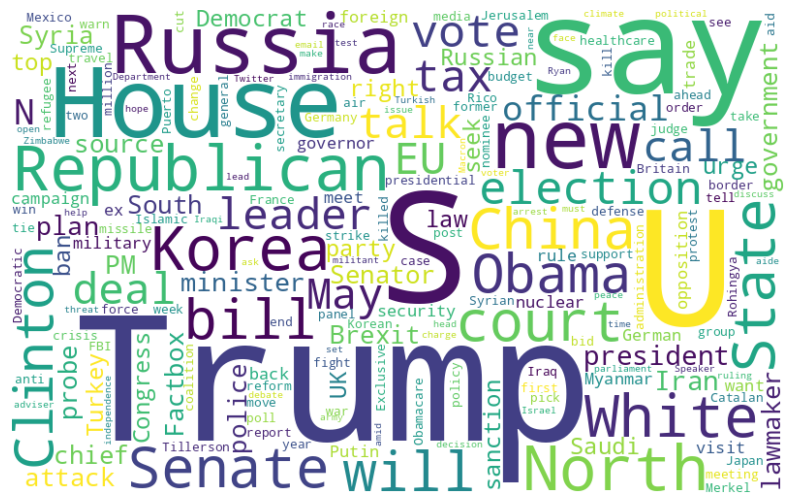

In [6]:
from wordcloud import WordCloud

real_titles = true_df.title
real_titles_ls = [text for text in real_titles]
real_all_words = ' '.join(real_titles)
wordcloud_real = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(real_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.show()

## Fake News Word Cloud

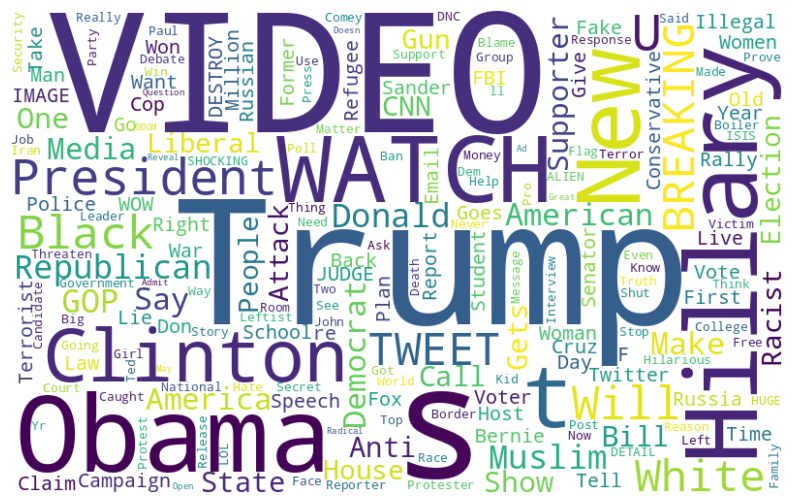

In [7]:
fake_titles = fake_df.title
fake_titles_ls = [text for text in fake_titles]
fake_all_words = ' '.join(fake_titles)
wordcloud_fake = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(fake_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.show()

# Data Preprocessing

## Data Combination

In [8]:
true_df['true'] = 1
fake_df['true'] = 0

df = pd.concat([true_df, fake_df])
display(df)

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


## Inspect Lengths of News

In [9]:
titles = [text for text in df.title]

max_len = 0
titles_len = []
for title in titles:
    titles_len.append(len(title.split()))
    max_len = max(len(title.split()), max_len)

print('Number of titles:', len(titles))
print('Max length of the titles:', max_len)
print('Mean length of the titles:', np.mean(titles_len))

Number of titles: 44898
Max length of the titles: 42
Mean length of the titles: 12.453472315025168


/tmp/ipykernel_3129/1580412618.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=50)


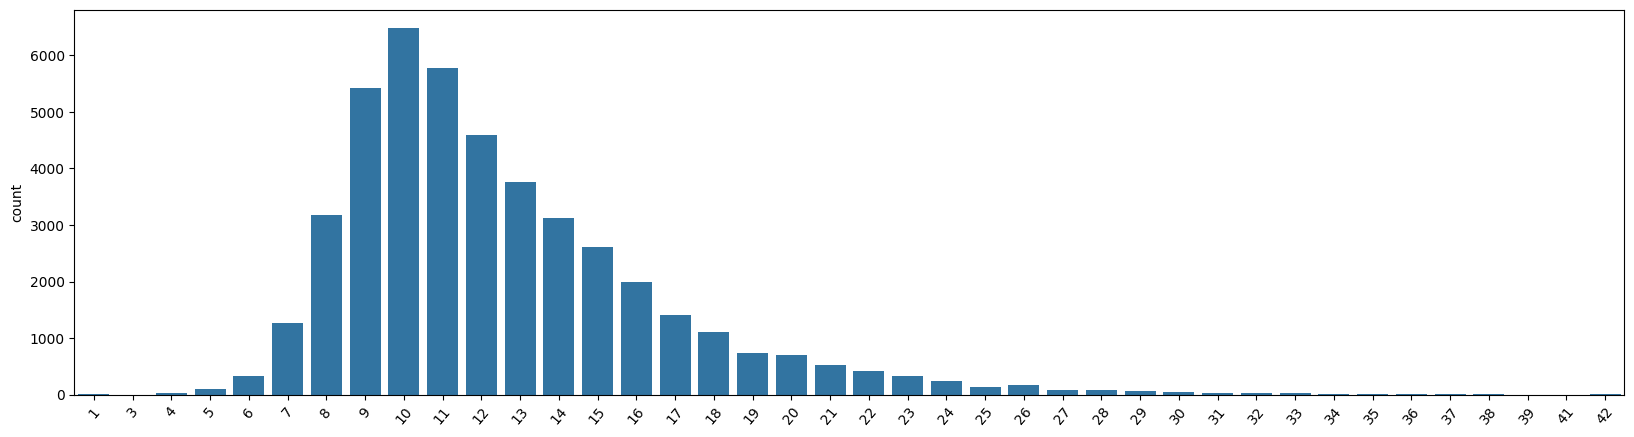

In [10]:
plt.figure(figsize=(20,5))
g = sns.countplot(x=titles_len)
g.set_xticklabels(g.get_xticklabels(), rotation=50)
plt.show()

In [11]:
texts = [text for text in df.text]

max_len = 0
texts_len = []
for text in texts:
    texts_len.append(len(text.split()))
    max_len = max(len(text.split()), max_len)

print('Mean length of the texts:', np.mean(texts_len))

Mean length of the texts: 405.28228428883244


## Purify & Shffle the DataFrame

In [12]:
from sklearn.utils import shuffle

df = df.iloc[:,[0, -1]]

df = shuffle(df).reset_index(drop=True)

display(df)

,title,true
0,Trump's defense chief sees no military collabo...,1
1,"Brexit talks stutter, but EU leaders might giv...",1
2,MEET CONSERVATIVE MUSLIM Steve Bannon Hired Fo...,0
3,"Venezuela defends rights record at U.N., says ...",1
4,Trump Crushed As Ex-KKK Leader Bashes Him For...,0
...,...,...
44893,"Trump Throws An EPIC, Brain-Melting Tantrum A...",0
44894,COMMUNIST VIETNAMESE LEADER THANKS U.S. Anti-W...,0
44895,WHOA! PAUL RYAN JUST LIED TO O’REILLY About Bi...,0
44896,CENSORED: CRANKY BERNIE Calls CNN “Fake News” ...,0


## Split Data into Training, Validation, Test

In [13]:
train_val_df = df.sample(frac = 0.8)
test_df = df.drop(train_val_df.index)

train_df = train_val_df.sample(frac = 0.8)
val_df = train_val_df.drop(train_df.index)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('valset size:', val_df.shape)
print('testset size:', test_df.shape)

trainset size: (28734, 2)
valset size: (7184, 2)
testset size: (8980, 2)


## Data distribution imbalanced

In [14]:
train_imbalanced = 1/10
val_imbalanced = 1/10
test_imbalanced = 1/10

train_true = train_df[train_df['true'] == 1]
train_fake = train_df[train_df['true'] == 0]
train_fake = train_fake.iloc[:round(len(train_fake)*train_imbalanced),:]
train_true_len = len(train_true)
train_fake_len = len(train_fake)
train_df = pd.concat([train_true, train_fake])
train_df = shuffle(train_df).reset_index(drop=True)

val_true = val_df[val_df['true'] == 1]
val_fake = val_df[val_df['true'] == 0]
val_fake = val_fake.iloc[:round(len(val_fake)*val_imbalanced),:]
val_true_len = len(val_true)
val_fake_len = len(val_fake)
val_df = pd.concat([val_true, val_fake])
val_df = shuffle(val_df).reset_index(drop=True)

test_true = test_df[test_df['true'] == 1]
test_fake = test_df[test_df['true'] == 0]
test_fake = test_fake.iloc[:round(len(test_fake)*test_imbalanced),:]
test_true_len = len(test_true)
test_fake_len = len(test_fake)
test_df = pd.concat([test_true, test_fake])
test_df = shuffle(test_df).reset_index(drop=True)

len_df = pd.DataFrame({'ind': ['Train', 'Validation', 'Test'], 'True': [train_true_len, val_true_len, test_true_len], 'Fake': [train_fake_len, val_fake_len, test_fake_len]})
len_df.set_index('ind', inplace=True)
len_df.index.name = None

len_df

,True,Fake
Train,13758,1498
Validation,3418,377
Test,4241,474


## Dataframe to csv

In [15]:
train_df.to_csv('train.tsv', sep='\t', index=False)
val_df.to_csv('val.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)

## Concatenate all dataframe

In [16]:
df = pd.concat([train_df, val_df, test_df])
df

,title,true
0,Myanmar urges Rohingya Muslims to help hunt in...,1
1,Trump order paves way for agencies to weaken h...,1
2,BREAKING: D.C. Driver Plows Into Capitol Polic...,0
3,U.S. sentencing reform backers cite success at...,1
4,"Possible Thales, Leonardo role in Franco-Itali...",1
...,...,...
4710,S&P ratchets up pressure on Alaska over budget,1
4711,INTERVIEW: Did the ‘Alt Right’ Die in Charlott...,0
4712,Kurds block Iraqi forces' access to Kirkuk oil...,1
4713,Lockheed Martin wins $582 million U.S. defense...,1


## Performing Data Cleaning

In [17]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

In [19]:
def preprocess(text):
    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3 and token not in stop_words:
            result.append(token)

    return result

In [20]:
import importlib.util

if importlib.util.find_spec("gensim") is None:
    !pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.5 MB/s eta 0:00:00


In [21]:
import gensim

df['clean'] = df['title'].apply(preprocess)

## Obtaining The Total Words Present In The Dataset

In [22]:
list_of_words = []
for i in df.clean:
    for j in i:
        list_of_words.append(j)

total_words = len(list(set(list_of_words)))
total_words

14171

## Preparing The Data By Performing Tokenization And Padding

In [23]:
from nltk import word_tokenize

In [24]:
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer

tokenizer = Tokenizer(num_words = total_words)
tokenizer.fit_on_texts(train_df['title'])

train_sequences = tokenizer.texts_to_sequences(train_df['title'])
val_sequences = tokenizer.texts_to_sequences(val_df['title'])
test_sequences = tokenizer.texts_to_sequences(test_df['title'])

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_train = pad_sequences(train_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_val = pad_sequences(val_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_test = pad_sequences(test_sequences,maxlen = 42, padding = 'post', truncating = 'post')

# BERT

In [26]:
!pip install transformers

import torch
from transformers import BertTokenizer

In [27]:
PRETRAINED_MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## Load Dataset Class

In [28]:
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, mode, tokenizer):
        assert mode in ['train', 'val', 'test']
        self.mode = mode
        self.df = pd.read_csv(mode + '.tsv', sep='\t').fillna("")
        self.len = len(self.df)
        self.tokenizer = tokenizer  # BERT tokenizer

    def __getitem__(self, idx):
        if self.mode == 'test':
            statement, label = self.df.iloc[idx, :].values
            label_tensor = torch.tensor(label)
        else:
            statement, label = self.df.iloc[idx, :].values
            label_tensor = torch.tensor(label)

        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['[SEP]']
        len_st = len(word_pieces)


        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len


trainset = FakeNewsDataset('train', tokenizer=tokenizer)
valset = FakeNewsDataset('val', tokenizer=tokenizer)
testset = FakeNewsDataset('test', tokenizer=tokenizer)

print('trainset size:' ,trainset.__len__())
print('valset size:',valset.__len__())
print('testset size: ',testset.__len__())

trainset size: 15256
valset size: 3795
testset size:  4715


## Sampling and Observing Tensors

In [29]:
sample_idx = 0

statement, label = trainset.df.iloc[sample_idx].values

tokens_tensor, segments_tensor, label_tensor = trainset[sample_idx]

tokens = tokenizer.convert_ids_to_tokens(tokens_tensor.tolist())
combined_text = " ".join(tokens)

print(f"""
original_statement:
{statement}

tokens:
{tokens}

label: {label}

--------------------

tokens_tensor:
{tokens_tensor}

segments_tensor:
{segments_tensor}

label_tensor:
{label_tensor}

""")


original_statement:
Myanmar urges Rohingya Muslims to help hunt insurgents amid deadly violence

tokens:
['[CLS]', 'myanmar', 'urges', 'ro', '##hing', '##ya', 'muslims', 'to', 'help', 'hunt', 'insurgents', 'amid', 'deadly', 'violence', '[SEP]']

label: 1

--------------------

tokens_tensor:
tensor([  101, 12620, 23876, 20996, 12053,  3148,  7486,  2000,  2393,  5690,
        20541, 13463,  9252,  4808,   102])

segments_tensor:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

label_tensor:
1




## Reforming the Dataset to Fit the Model

In [30]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids


BATCH_SIZE = 16
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)
valloader = DataLoader(valset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)
testloader = DataLoader(testset, batch_size=BATCH_SIZE,collate_fn=create_mini_batch)

In [31]:
data = next(iter(trainloader))

tokens_tensors, segments_tensors, masks_tensors, label_ids = data

print(f"""
tokens_tensors.shape   = {tokens_tensors.shape}
{tokens_tensors}
------------------------
segments_tensors.shape = {segments_tensors.shape}
{segments_tensors}
------------------------
masks_tensors.shape    = {masks_tensors.shape}
{masks_tensors}
------------------------
label_ids.shape        = {label_ids.shape}
{label_ids}
""")


tokens_tensors.shape   = torch.Size([16, 25])
tensor([[  101, 12620, 23876, 20996, 12053,  3148,  7486,  2000,  2393,  5690,
         20541, 13463,  9252,  4808,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  8398,  2344,  6643,  6961,  2126,  2005,  6736,  2000, 23021,
          2740,  2375,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  4911,  1024,  1040,  1012,  1039,  1012,  4062, 20228, 15568,
          2046,  9424,  2610,  1529,  7171,  5045,   102,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  1057,  1012,  1055,  1012, 23280,  5290,  2067,  2545, 21893,
          3112,  2012,  2110,  2504,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  2825, 22794,  4244,  1010, 14720,  2535,  1999,  9341,  1011,
          3059,  2911,  7566,  1024,  4216,   102,     0,     

## Model Construction

In [32]:
from transformers import BertForSequenceClassification
from IPython.display import display, clear_output

PRETRAINED_MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 2

model = BertForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL_NAME, num_labels=NUM_LABELS)

clear_output()

print("""
name             module
-----------------------""")
for name, module in model.named_children():
    if name == "bert":
        for n, _ in module.named_children():
            print(f"{name}:{n}")
    else:
        print("{:16} {}".format(name, module))


name             module
-----------------------
bert:embeddings
bert:encoder
bert:pooler
dropout          Dropout(p=0.1, inplace=False)
classifier       Linear(in_features=768, out_features=2, bias=True)


In [33]:
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.12.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

## Fine-Tuning of BERT

In [34]:
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)
model = model.to(device)

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()

        outputs = model(input_ids=tokens_tensors,
                        token_type_ids=segments_tensors,
                        attention_mask=masks_tensors,
                        labels=labels)

        loss = outputs[0]
        loss.backward()
        optimizer.step()

        logits = outputs[1]
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist() , labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        loop.set_postfix(acc = train_acc, loss = train_loss)

device: cuda:0


  0%|          | 0/954 [00:00<?, ?it/s]

  0%|          | 0/954 [00:00<?, ?it/s]

  0%|          | 0/954 [00:00<?, ?it/s]

## Save Model

In [35]:
torch.save(model, './best_model.pth')
print('Model saved!')

Model saved!


## Load Model

## Test

[[0.99435294 0.03225806]
 [0.00564706 0.96774194]]
Acc:  0.991728525980912


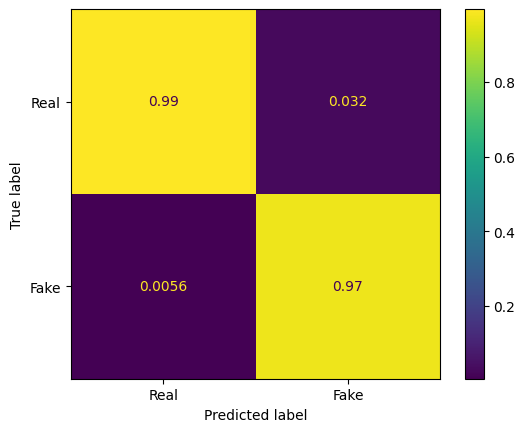

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true=[]
predictions=[]
with torch.no_grad():
    model.eval()
    for data in testloader:
        if next(model.parameters()).is_cuda:
            data = [t.to(device) for t in data if t is not None]

        tokens_tensors, segments_tensors, masks_tensors = data[:3]
        test_outputs = model(input_ids=tokens_tensors,
                    token_type_ids=segments_tensors,
                    attention_mask=masks_tensors)

        logits = test_outputs[0]
        _, pred = torch.max(logits.data, 1)

        labels = data[3]
        true.extend(labels.cpu().tolist())
        predictions.extend(pred.cpu().tolist())


cm = confusion_matrix(true, predictions, labels=[1, 0], normalize='pred')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot()

print('Acc: ', accuracy_score(predictions,true))

In [37]:
df = pd.DataFrame({"pred_label": predictions})

df_pred = pd.concat([testset.df.loc[:, ['title']],
                          testset.df.loc[:, ['true']],
                          df.loc[:, 'pred_label']], axis=1)
df_pred

,title,true,pred_label
0,Peru's Kuczynski eyes VP for prime minister af...,1,1
1,Egyptian rights lawyer says he'll run for pres...,1,1
2,Lebanese army to deploy along entire eastern b...,1,1
3,Chance of 'no deal' Brexit rises to 1-in-4: JP...,1,1
4,Puerto Rico opens arms to refugees from Irma's...,1,1
...,...,...,...
4710,S&P ratchets up pressure on Alaska over budget,1,1
4711,INTERVIEW: Did the ‘Alt Right’ Die in Charlott...,0,0
4712,Kurds block Iraqi forces' access to Kirkuk oil...,1,1
4713,Lockheed Martin wins $582 million U.S. defense...,1,1


In [38]:
from sklearn.metrics import classification_report
print(classification_report(df_pred.true, df_pred.pred_label))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       474
           1       0.99      1.00      1.00      4241

    accuracy                           0.99      4715
   macro avg       0.98      0.97      0.98      4715
weighted avg       0.99      0.99      0.99      4715



## Insight on Wrong Classification

/tmp/ipykernel_3129/3983237041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')


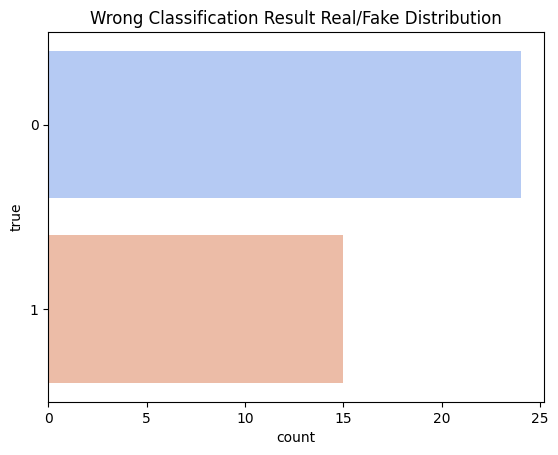

In [39]:
wrong_df = df_pred[df_pred.true != df_pred.pred_label]
sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')
plt.show()

In [40]:
wrong_titles = df_pred[df_pred.true != df_pred.pred_label].title.values
wrong_titles

array([' With Irma About To Strike Florida, Trump Begs For Donations To His Re-Election Campaign',
       'Trump Administration Faces Flood of Lawsuits Over Executive Immigration Ban',
       'Trump Asks Congress To Investigate Former Obama Administration',
       'Google is the Engine of Censorship',
       ' Five Struggles Working Americans Face That Trump Will NEVER Understand',
       'REPORT: PRESIDENT TRUMP To Replace Sean Spicer With FOX News Personality',
       'Pro-Trump groups take no prisoners in rush to help an embattled president',
       ' Kim Jong Un And North Korean Media Enthusiastically Want Trump To Become President',
       'Separate mothers and children: How a Trump threat deterred illegal migrants',
       'Children serenade pope on 81st birthday; he appeals for kidnapped nuns',
       ' Bush Speechwriter LEVELS Trump With This Devastating Inauguration Day Tweet',
       'CHURCH REPLACES JESUS In Nativity Scene With Drowned Muslim Syrian Boy',
       'CNN Fake Ne

# Real-Time Prediction

In [41]:
import torch
import pandas as pd

sample_headlines = [
    "Government launches new scholarship program for students",
    "NASA confirms the Earth is flat and hiding the truth",
    "University announces admissions for the next academic session"
]

results = []

model.eval()

for headline in sample_headlines:

    inputs = tokenizer(
        headline,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=42
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    label = "Real News" if prediction == 1 else "Fake News"

    results.append([headline, label])

df_results = pd.DataFrame(
    results,
    columns=["News Headline", "Prediction"]
)

print(df_results)

                                       News Headline Prediction
0  Government launches new scholarship program fo...  Real News
1  NASA confirms the Earth is flat and hiding the...  Real News
2  University announces admissions for the next a...  Real News
